# Redes Neurais e Deep Learning — Lista de Exercícios

Notebook preparado para o **Google Colaboratory**.

> Recomendação: ative a GPU em **Ambiente de execução → Alterar o tipo de ambiente de execução → GPU (T4)**. Não é obrigatório, mas acelera as questões 1, 2 e 4.

**Ferramentas utilizadas:** PyTorch + TorchVision (Q1), Ultralytics YOLOv8 (Q2), TensorFlow/Keras (Q3 e Q4), scikit-learn, seaborn e matplotlib.

Cada questão usa **redes pré-treinadas** quando exigido, com os comandos de download/importação explícitos.

---
## Questão 1 — Classificação de imagens na CIFAR-10 com CNN pré-treinada

A base **CIFAR-10** possui 60.000 imagens coloridas 32×32 (50.000 treino / 10.000 teste) em 10 classes:
`avião, automóvel, pássaro, gato, cervo, cachorro, sapo, cavalo, navio, caminhão`.

**Rede pré-treinada usada:** uma **ResNet-20** já treinada na CIFAR-10, disponível no repositório público
[`chenyaofo/pytorch-cifar-models`](https://github.com/chenyaofo/pytorch-cifar-models) e carregada diretamente via `torch.hub`
(não precisamos treinar nada — apenas baixamos os pesos).

**O que o código faz:**
1. Baixa o conjunto de **teste** da CIFAR-10 (10.000 imagens) com a normalização usada no treino do modelo.
2. Carrega a CNN pré-treinada e roda a inferência em todo o conjunto de teste.
3. Calcula a acurácia e apresenta o desempenho na forma de **matriz de confusão** (10×10).

In [ ]:
# Q1 - dependências (já presentes no Colab; instalação garante versões compatíveis)
!pip install -q torch torchvision scikit-learn seaborn matplotlib

In [ ]:
# Q1 - Classificação CIFAR-10 com CNN pré-treinada (ResNet-20)
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

# Normalização média/desvio-padrão usada no treino dos modelos CIFAR-10 do repositório
mean = [0.4914, 0.4822, 0.4465]
std  = [0.2470, 0.2435, 0.2616]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Download automático do conjunto de TESTE (10 mil imagens)
testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

# Ordem oficial das classes na CIFAR-10
classes = ['aviao','automovel','passaro','gato','cervo','cachorro','sapo','cavalo','navio','caminhao']

# Carrega a CNN JÁ TREINADA via torch.hub (faz o download dos pesos automaticamente)
model = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
model = model.to(device).eval()

# Inferência em todo o conjunto de teste
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in testloader:
        imgs = imgs.to(device)
        out = model(imgs)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
acc = (all_preds == all_labels).mean()
print(f"\nAcurácia no conjunto de teste (10.000 imagens): {acc*100:.2f}%")

Dispositivo: cuda


100%|██████████| 170M/170M [00:03<00:00, 43.3MB/s]


The repository chenyaofo_pytorch-cifar-models does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt


100%|██████████| 1.09M/1.09M [00:00<00:00, 35.6MB/s]



Acurácia no conjunto de teste (10.000 imagens): 92.12%


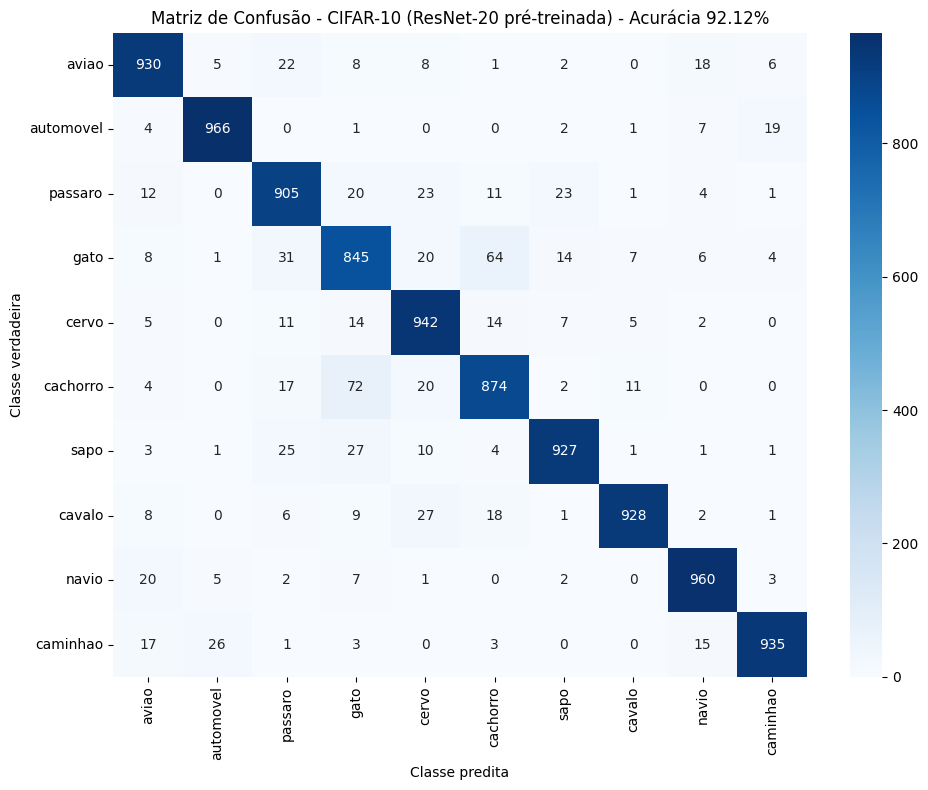

              precision    recall  f1-score   support

       aviao       0.92      0.93      0.92      1000
   automovel       0.96      0.97      0.96      1000
     passaro       0.89      0.91      0.90      1000
        gato       0.84      0.84      0.84      1000
       cervo       0.90      0.94      0.92      1000
    cachorro       0.88      0.87      0.88      1000
        sapo       0.95      0.93      0.94      1000
      cavalo       0.97      0.93      0.95      1000
       navio       0.95      0.96      0.95      1000
    caminhao       0.96      0.94      0.95      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [ ]:
# Q1 - Matriz de confusão
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Classe predita")
plt.ylabel("Classe verdadeira")
plt.title(f"Matriz de Confusão - CIFAR-10 (ResNet-20 pré-treinada) - Acurácia {acc*100:.2f}%")
plt.tight_layout()
plt.show()

# Relatório por classe (precisão, revocação, F1)
print(classification_report(all_labels, all_preds, target_names=classes))

---
## Questão 2 — Detecção de objetos e segmentação com YOLO

Usamos a biblioteca **Ultralytics YOLOv8**, com modelos **pré-treinados** na base **COCO** (80 classes), de uso livre.
Os pesos são baixados automaticamente na primeira execução:

- **(a) Detecção** → `yolov8n.pt` (caixas delimitadoras + classe + confiança).
- **(b) Segmentação** → `yolov8n-seg.pt` (máscaras de segmentação de cada objeto, além da caixa).

A imagem é de livre escolha; usamos uma imagem de exemplo pública. Para usar **sua própria imagem** no Colab, basta
fazer upload (ícone de pasta à esquerda) e trocar o caminho do arquivo.

In [6]:
# Q2 - instalação do Ultralytics YOLOv8
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.1 MB/s eta 0:00:00


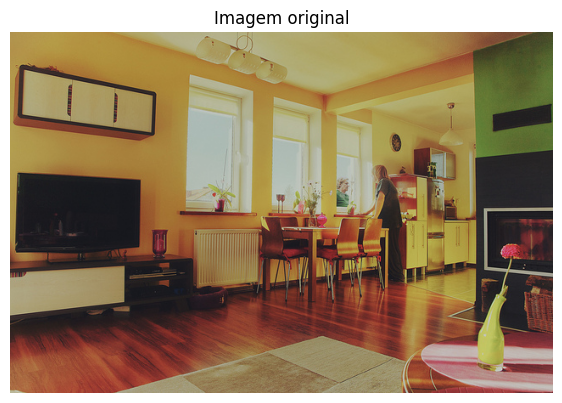

In [7]:
# Q2 - imagem de livre escolha (baixada da web). Troque por sua imagem se desejar.
import urllib.request
import matplotlib.pyplot as plt

url = "http://images.cocodataset.org/val2017/000000000139.jpg"   # imagem de exemplo pública
urllib.request.urlretrieve(url, "cena.jpg")

plt.figure(figsize=(7,7))
plt.imshow(plt.imread("cena.jpg"))
plt.axis('off'); plt.title("Imagem original"); plt.show()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/cena.jpg: 448x640 1 person, 5 chairs, 1 potted plant, 2 dining tables, 1 tv, 1 refrigerator, 1 clock, 1 vase, 66.9ms
Speed: 5.0ms preprocess, 66.9ms inference, 41.4ms postprocess per image at shape (1, 3, 448, 640)
Objetos detectados:
  - tv (confiança 0.93)
  - chair (confiança 0.85)
  - person (confiança 0.71)
  - chair (confiança 0.52)
  - chair (confiança 0.51)
  - chair (confiança 0.51)
  - potted plant (confiança 0.42)
  - vase (confiança 0.39)
  - refrigerator (confiança 0.36)
  - dining table (confiança 0.28)
  - clock (confiança 0.28)
  - dining table (confiança 0.27)
  - chair (confiança 0.27)


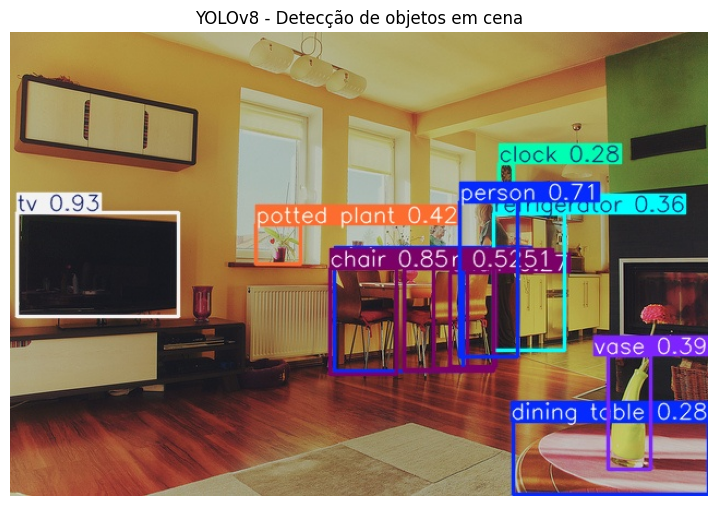

In [8]:
# Q2 (a) - DETECÇÃO de objetos com YOLOv8 pré-treinada (COCO)
from ultralytics import YOLO

det_model = YOLO("yolov8n.pt")          # download automático dos pesos
det_res = det_model("cena.jpg")          # inferência
det_res[0].save(filename="deteccao.jpg") # imagem anotada

# Lista de objetos detectados
names = det_model.names
print("Objetos detectados:")
for b in det_res[0].boxes:
    cls = int(b.cls[0]); conf = float(b.conf[0])
    print(f"  - {names[cls]} (confiança {conf:.2f})")

plt.figure(figsize=(9,9))
plt.imshow(plt.imread("deteccao.jpg"))
plt.axis('off'); plt.title("YOLOv8 - Detecção de objetos em cena"); plt.show()


image 1/1 /content/cena.jpg: 448x640 1 person, 3 chairs, 2 potted plants, 1 dining table, 2 tvs, 1 refrigerator, 1 clock, 1 vase, 17.6ms
Speed: 1.6ms preprocess, 17.6ms inference, 33.5ms postprocess per image at shape (1, 3, 448, 640)


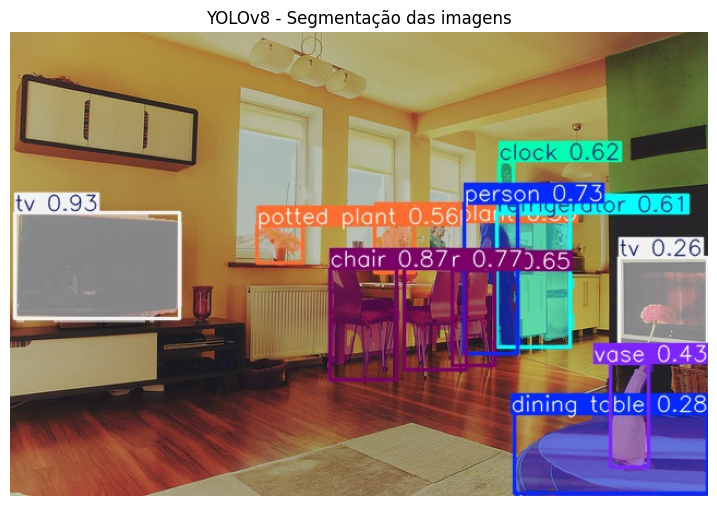

In [9]:
# Q2 (b) - SEGMENTAÇÃO (semântica/instâncias) com YOLOv8-seg pré-treinada
seg_model = YOLO("yolov8n-seg.pt")           # download automático dos pesos
seg_res = seg_model("cena.jpg")               # inferência com máscaras
seg_res[0].save(filename="segmentacao.jpg")

plt.figure(figsize=(9,9))
plt.imshow(plt.imread("segmentacao.jpg"))
plt.axis('off'); plt.title("YOLOv8 - Segmentação das imagens"); plt.show()

---
## Questão 3 — Visualização de dados 8D com Autoencoder (8 → 2)

Geramos **quatro nuvens gaussianas** em $\mathbb{R}^8$, todas com **variância unitária** e centros:

$$m_1=(0,0,0,0,0,0,0,0),\; m_2=(4,0,0,0,0,0,0,0),\; m_3=(0,0,0,4,0,0,0,0),\; m_4=(0,0,0,0,0,0,0,4)$$

Treinamos um **autoencoder** com camada latente de dimensão **2**. A arquitetura é simétrica:
`8 → 6 → 4 → 2 (latente) → 4 → 6 → 8`. O **encoder** projeta os dados de 8D para 2D, permitindo a visualização.
A função de perda é o erro quadrático médio (MSE) da reconstrução.

In [ ]:
# Q3 - Autoencoder para reduzir 8D -> 2D
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

np.random.seed(42); tf.random.set_seed(42)

n_por_classe = 500
dim = 8
centers = {
    'C1': np.array([0,0,0,0,0,0,0,0], dtype='float32'),
    'C2': np.array([4,0,0,0,0,0,0,0], dtype='float32'),
    'C3': np.array([0,0,0,4,0,0,0,0], dtype='float32'),
    'C4': np.array([0,0,0,0,0,0,0,4], dtype='float32'),
}

X, y = [], []
for i, (nome, m) in enumerate(centers.items()):
    # variância unitária -> desvio-padrão 1 -> randn + centro
    X.append(np.random.randn(n_por_classe, dim).astype('float32') + m)
    y += [i] * n_por_classe
X = np.vstack(X); y = np.array(y)
print("Formato dos dados:", X.shape)

# Arquitetura simétrica do autoencoder
inp = keras.Input(shape=(dim,))
e = layers.Dense(6, activation='relu')(inp)
e = layers.Dense(4, activation='relu')(e)
latent = layers.Dense(2, activation='linear', name='latente')(e)   # espaço 2D
d = layers.Dense(4, activation='relu')(latent)
d = layers.Dense(6, activation='relu')(d)
out = layers.Dense(dim, activation='linear')(d)

autoencoder = keras.Model(inp, out)
encoder = keras.Model(inp, latent)     # usado para projetar em 2D
autoencoder.compile(optimizer='adam', loss='mse')

hist = autoencoder.fit(X, X, epochs=100, batch_size=32, verbose=0)
print("Perda final (MSE de reconstrução):", hist.history['loss'][-1])

Formato dos dados: (2000, 8)
Perda final (MSE de reconstrução): 0.7487527132034302


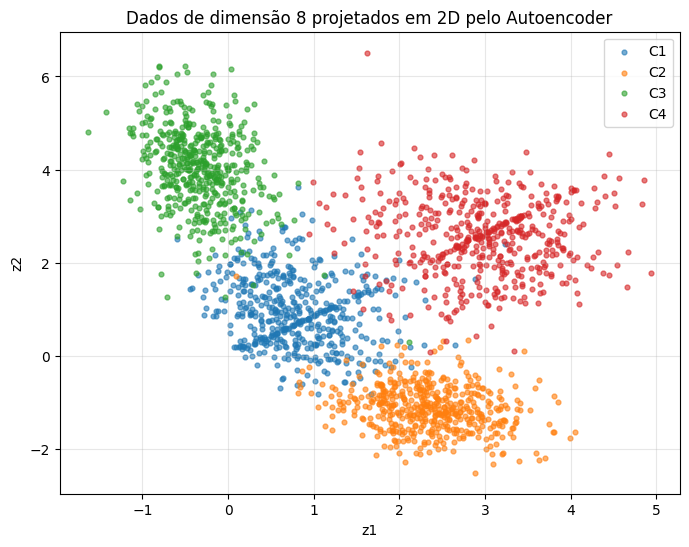

In [ ]:
# Q3 - Projeção dos dados no novo espaço 2D
Z = encoder.predict(X, verbose=0)

plt.figure(figsize=(8,6))
cores = ['tab:blue','tab:orange','tab:green','tab:red']
for i, nome in enumerate(centers):
    plt.scatter(Z[y==i,0], Z[y==i,1], s=12, c=cores[i], label=nome, alpha=0.6)
plt.legend(); plt.xlabel("z1"); plt.ylabel("z2")
plt.title("Dados de dimensão 8 projetados em 2D pelo Autoencoder")
plt.grid(True, alpha=0.3); plt.show()

**Observação:** como os centros estão bem separados (distância 4 entre médias com desvio-padrão 1), o autoencoder
consegue posicionar as quatro classes em regiões distintas do plano 2D, evidenciando a estrutura de agrupamento.

---
## Questão 4 — Predição de série temporal (NARX e LSTM)

Série definida por:
$$x(n) = v(n) + \beta\, v(n-1)\, v(n-2), \quad \beta = 0{,}5$$
onde $v(n)$ é ruído branco gaussiano de **variância unitária**. A série tem média zero e variância
$\sigma_x^2 = \sigma_v^2 + \beta^2 \sigma_v^2$.

Trata-se de um processo **MA não linear**. A parcela $v(n)$ é puramente aleatória (não previsível); o que pode ser
aprendido é a parcela determinística $\beta\,v(n-1)v(n-2)$ a partir do **histórico da própria série**. Por isso o erro
residual fica próximo da variância do ruído — comportamento esperado (exemplo clássico de Haykin).

- **(a) NARX** — implementado como **MLP com linhas de atraso (tapped delay line)**: a entrada são os $p$ valores
  passados $x(n), x(n-1), \dots, x(n-p+1)$ e a saída é $\hat{x}(n+1)$. A realimentação global é a reapresentação dos
  valores passados da série como entrada.
- **(b) LSTM** — mesma janela de entrada, mas tratada como sequência temporal por uma rede recorrente LSTM.

Avaliamos cada rede mostrando: **série real**, **predição** e **erro** $e(n+1)=x(n+1)-\hat{x}(n+1)$.

Comprimento da série: 3000
Média ~ -0.025 | Variância ~ 1.208 (esperada = 1.250)


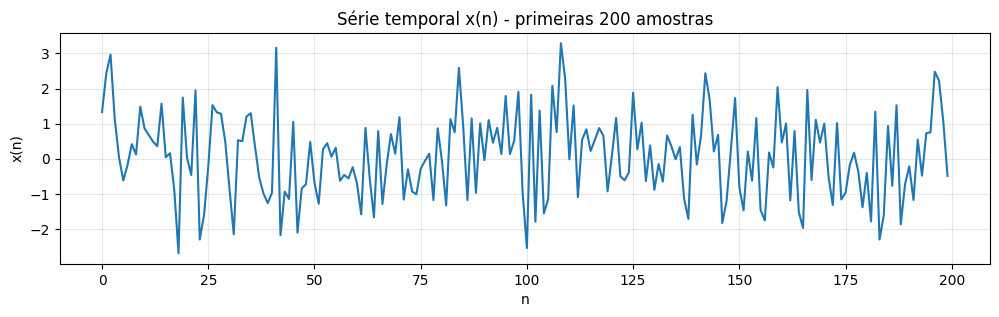

In [ ]:
# Q4 - Geração da série temporal
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(0); tf.random.set_seed(0)

N = 3000
beta = 0.5
v = np.random.randn(N + 2)     # ruído branco gaussiano, variância unitária
x = np.array([v[n] + beta * v[n-1] * v[n-2] for n in range(2, N + 2)], dtype='float32')

print(f"Comprimento da série: {len(x)}")
print(f"Média ~ {x.mean():.3f} | Variância ~ {x.var():.3f} (esperada = {1 + beta**2:.3f})")

plt.figure(figsize=(12,3))
plt.plot(x[:200]); plt.title("Série temporal x(n) - primeiras 200 amostras")
plt.xlabel("n"); plt.ylabel("x(n)"); plt.grid(True, alpha=0.3); plt.show()

In [ ]:
# Q4 - Construção do conjunto janelado (linhas de atraso)
p = 6   # ordem: número de valores passados usados como entrada

def make_dataset(serie, p):
    Xs, ys = [], []
    for i in range(p, len(serie)):
        Xs.append(serie[i-p:i])   # x(n-p+1) ... x(n)
        ys.append(serie[i])       # x(n+1)
    return np.array(Xs, dtype='float32'), np.array(ys, dtype='float32')

Xw, yw = make_dataset(x, p)
split = int(0.7 * len(Xw))
Xtr, Xte = Xw[:split], Xw[split:]
ytr, yte = yw[:split], yw[split:]
print("Treino:", Xtr.shape, "| Teste:", Xte.shape)

Treino: (2095, 6) | Teste: (899, 6)


In [ ]:
# Q4 (a) - Rede NARX (MLP com realimentação global / linhas de atraso)
narx = keras.Sequential([
    layers.Input(shape=(p,)),
    layers.Dense(20, activation='tanh'),
    layers.Dense(10, activation='tanh'),
    layers.Dense(1,  activation='linear')
])
narx.compile(optimizer='adam', loss='mse')
narx.fit(Xtr, ytr, epochs=60, batch_size=32, verbose=0)

pred_narx = narx.predict(Xte, verbose=0).flatten()
err_narx  = yte - pred_narx
mse_narx  = np.mean(err_narx**2)
print(f"NARX  -> MSE de predição: {mse_narx:.4f}")

NARX  -> MSE de predição: 1.0062


In [ ]:
# Q4 (b) - Rede LSTM
XtrL = Xtr.reshape(-1, p, 1)
XteL = Xte.reshape(-1, p, 1)

lstm = keras.Sequential([
    layers.Input(shape=(p, 1)),
    layers.LSTM(20),
    layers.Dense(1, activation='linear')
])
lstm.compile(optimizer='adam', loss='mse')
lstm.fit(XtrL, ytr, epochs=60, batch_size=32, verbose=0)

pred_lstm = lstm.predict(XteL, verbose=0).flatten()
err_lstm  = yte - pred_lstm
mse_lstm  = np.mean(err_lstm**2)
print(f"LSTM  -> MSE de predição: {mse_lstm:.4f}")

LSTM  -> MSE de predição: 0.9657


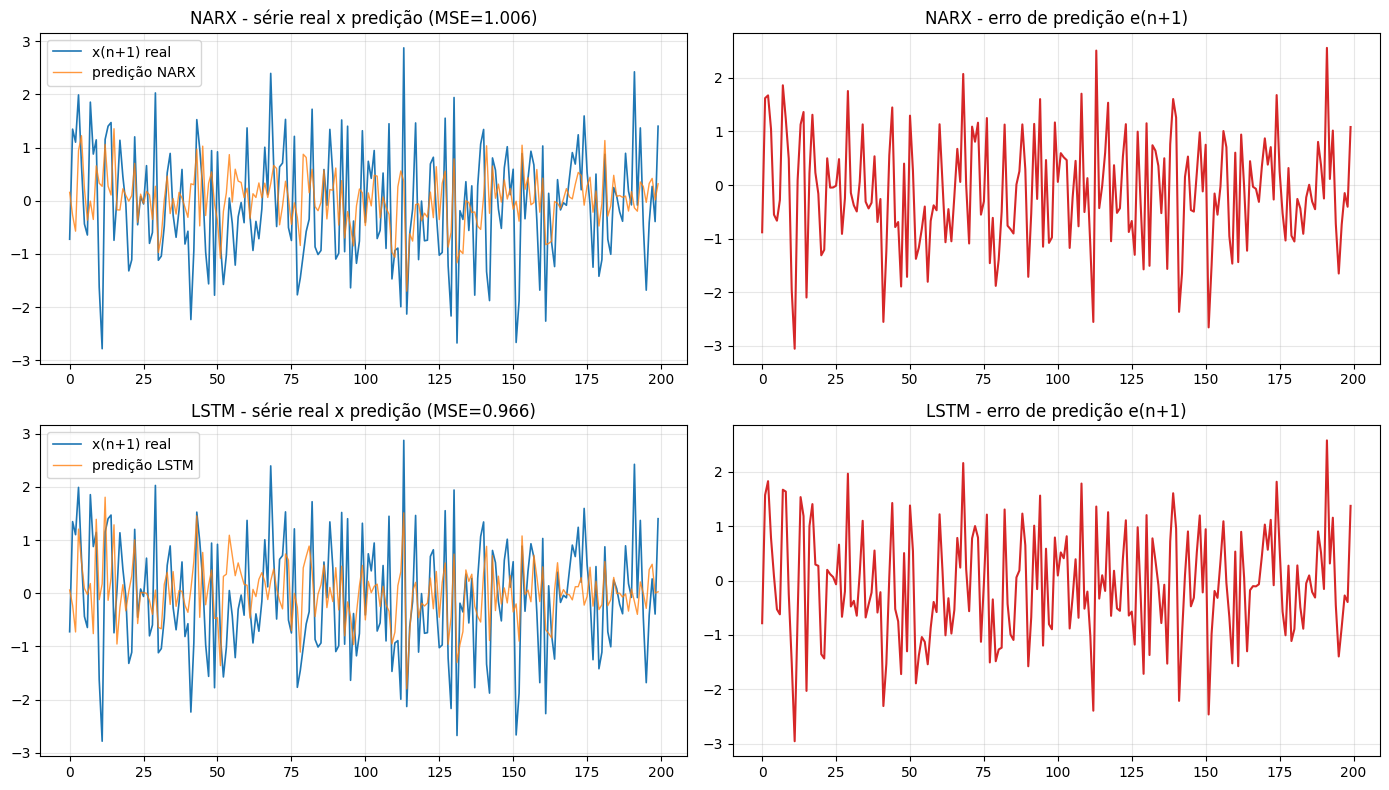

Comparação final -> MSE NARX: 1.0062 | MSE LSTM: 0.9657
Obs.: o erro fica próximo da variância do ruído branco (~1), pois v(n) é imprevisível;
as redes aprendem apenas a parcela determinística beta*v(n-1)*v(n-2).


In [ ]:
# Q4 - Avaliação: série real, predição e erro (NARX e LSTM)
M = 200  # janela de visualização

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# NARX
axes[0,0].plot(yte[:M], label="x(n+1) real", linewidth=1.2)
axes[0,0].plot(pred_narx[:M], label="predição NARX", linewidth=1.0, alpha=0.8)
axes[0,0].set_title(f"NARX - série real x predição (MSE={mse_narx:.3f})")
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(err_narx[:M], color='tab:red')
axes[0,1].set_title("NARX - erro de predição e(n+1)")
axes[0,1].grid(True, alpha=0.3)

# LSTM
axes[1,0].plot(yte[:M], label="x(n+1) real", linewidth=1.2)
axes[1,0].plot(pred_lstm[:M], label="predição LSTM", linewidth=1.0, alpha=0.8)
axes[1,0].set_title(f"LSTM - série real x predição (MSE={mse_lstm:.3f})")
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(err_lstm[:M], color='tab:red')
axes[1,1].set_title("LSTM - erro de predição e(n+1)")
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Comparação final -> MSE NARX: {mse_narx:.4f} | MSE LSTM: {mse_lstm:.4f}")
print("Obs.: o erro fica próximo da variância do ruído branco (~1), pois v(n) é imprevisível;")
print("as redes aprendem apenas a parcela determinística beta*v(n-1)*v(n-2).")